# vgg19

### Imports

In [1]:
# Добавляем текущую директорию в путь
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, datasets
from pathlib import Path
import logging
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from src.models import load_model, confusion_matrix, Trainer
from src.data import load_datasets, create_dataloaders
from src.utils import utils

%matplotlib inline

In [3]:
DIR = Path.cwd().parent

### Logging

In [4]:
# Настройка логгера
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

### Loading the configuration for the dataset

In [5]:
path_config_data = Path("../configs/data.yaml").absolute()
config_data = utils.load_config(path_config_data)

In [6]:
# Путь хранения датасета
path_data_load = Path(DIR, config_data["root_dir"])
train_dataset, val_dataset = load_datasets(path_data_load, config_data["image_size"])

In [7]:
# Создаем DataLoader
train_loader, val_loader = create_dataloaders(
        train_dataset,
        val_dataset,
        config_data['batch_size'],
        config_data['num_workers'])

### Loading the configuration for the model

In [8]:
path_config_model = Path("../configs/transfer_learning_vgg19.yaml").absolute()
config_dict = utils.load_config(path_config_model)
config_model = config_dict['model']

In [9]:
# Фиксируем random seed для воспроизводимости
utils.set_seed(config_model['seed'])

In [10]:
# Определение устройства
device_obj = torch.device(
    config_model['device'] if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device_obj}")

Using device: cuda


### Model VGG19

In [11]:
# VGG19 с заморозкой всех сверточных слоев
model = load_model(config_model['name'], config_model['num_classes'])
model = model.to(device_obj)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\RoyalPC/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 548M/548M [00:51<00:00, 11.1MB/s]


In [12]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=37, bias=True)
)

### Optimizer

In [13]:
# Оптимизатор и scheduler
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config_model['lr'],
    weight_decay=config_model['weight_decay'],
)

In [14]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-5, T_max=30)

### Train model

In [15]:
# Создание тренера
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device_obj,
    output_dir=Path(DIR, config_model['output_dir']),
    logger=logger,
)

### Epochs

In [16]:
# Устанавливаем начальную эпоку если ранее было обучение модель продолжит
# с того места на котором остановилось обучение
start_epoch:int = 0
checkpoint_path = Path(DIR, config_dict['resume'])
if config_dict.get('resume') and checkpoint_path.exists():
    checkpoint = trainer.load_checkpoint(checkpoint_path)
    start_epoch = checkpoint.get('epoch', 0) + 1
    print(f"Resumed from epoch {start_epoch}")

In [17]:
best_metric = trainer.train(
    num_epochs=config_model['epochs'],
    start_epoch=start_epoch,
)

Epoch 0 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [00:22<00:00,  5.20it/s, loss=2.92, acc=12.9]
INFO:__main__:Epoch 0: Train accuracy: 0.1293
Validating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [00:16<00:00,  6.81it/s]
INFO:__main__:Epoch 0: Val loss: 1.7030, Val accuracy: 0.3865
INFO:__main__:New best model saved with metric: 0.3865
Epoch 1 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [00:21<00:00,  5.26it/s, loss=1.68, acc=42.4]
INFO:__main__:Epoch 1: Train accuracy: 0.4239
Validating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [19]:
best_metric

0.9029708367402562

### best model checkpoint

In [16]:
best_model_checkpoint = trainer.load_checkpoint(Path(DIR, "./data/models/exp_vgg19_transfer/best_model.pth"))

### Confusion matrix

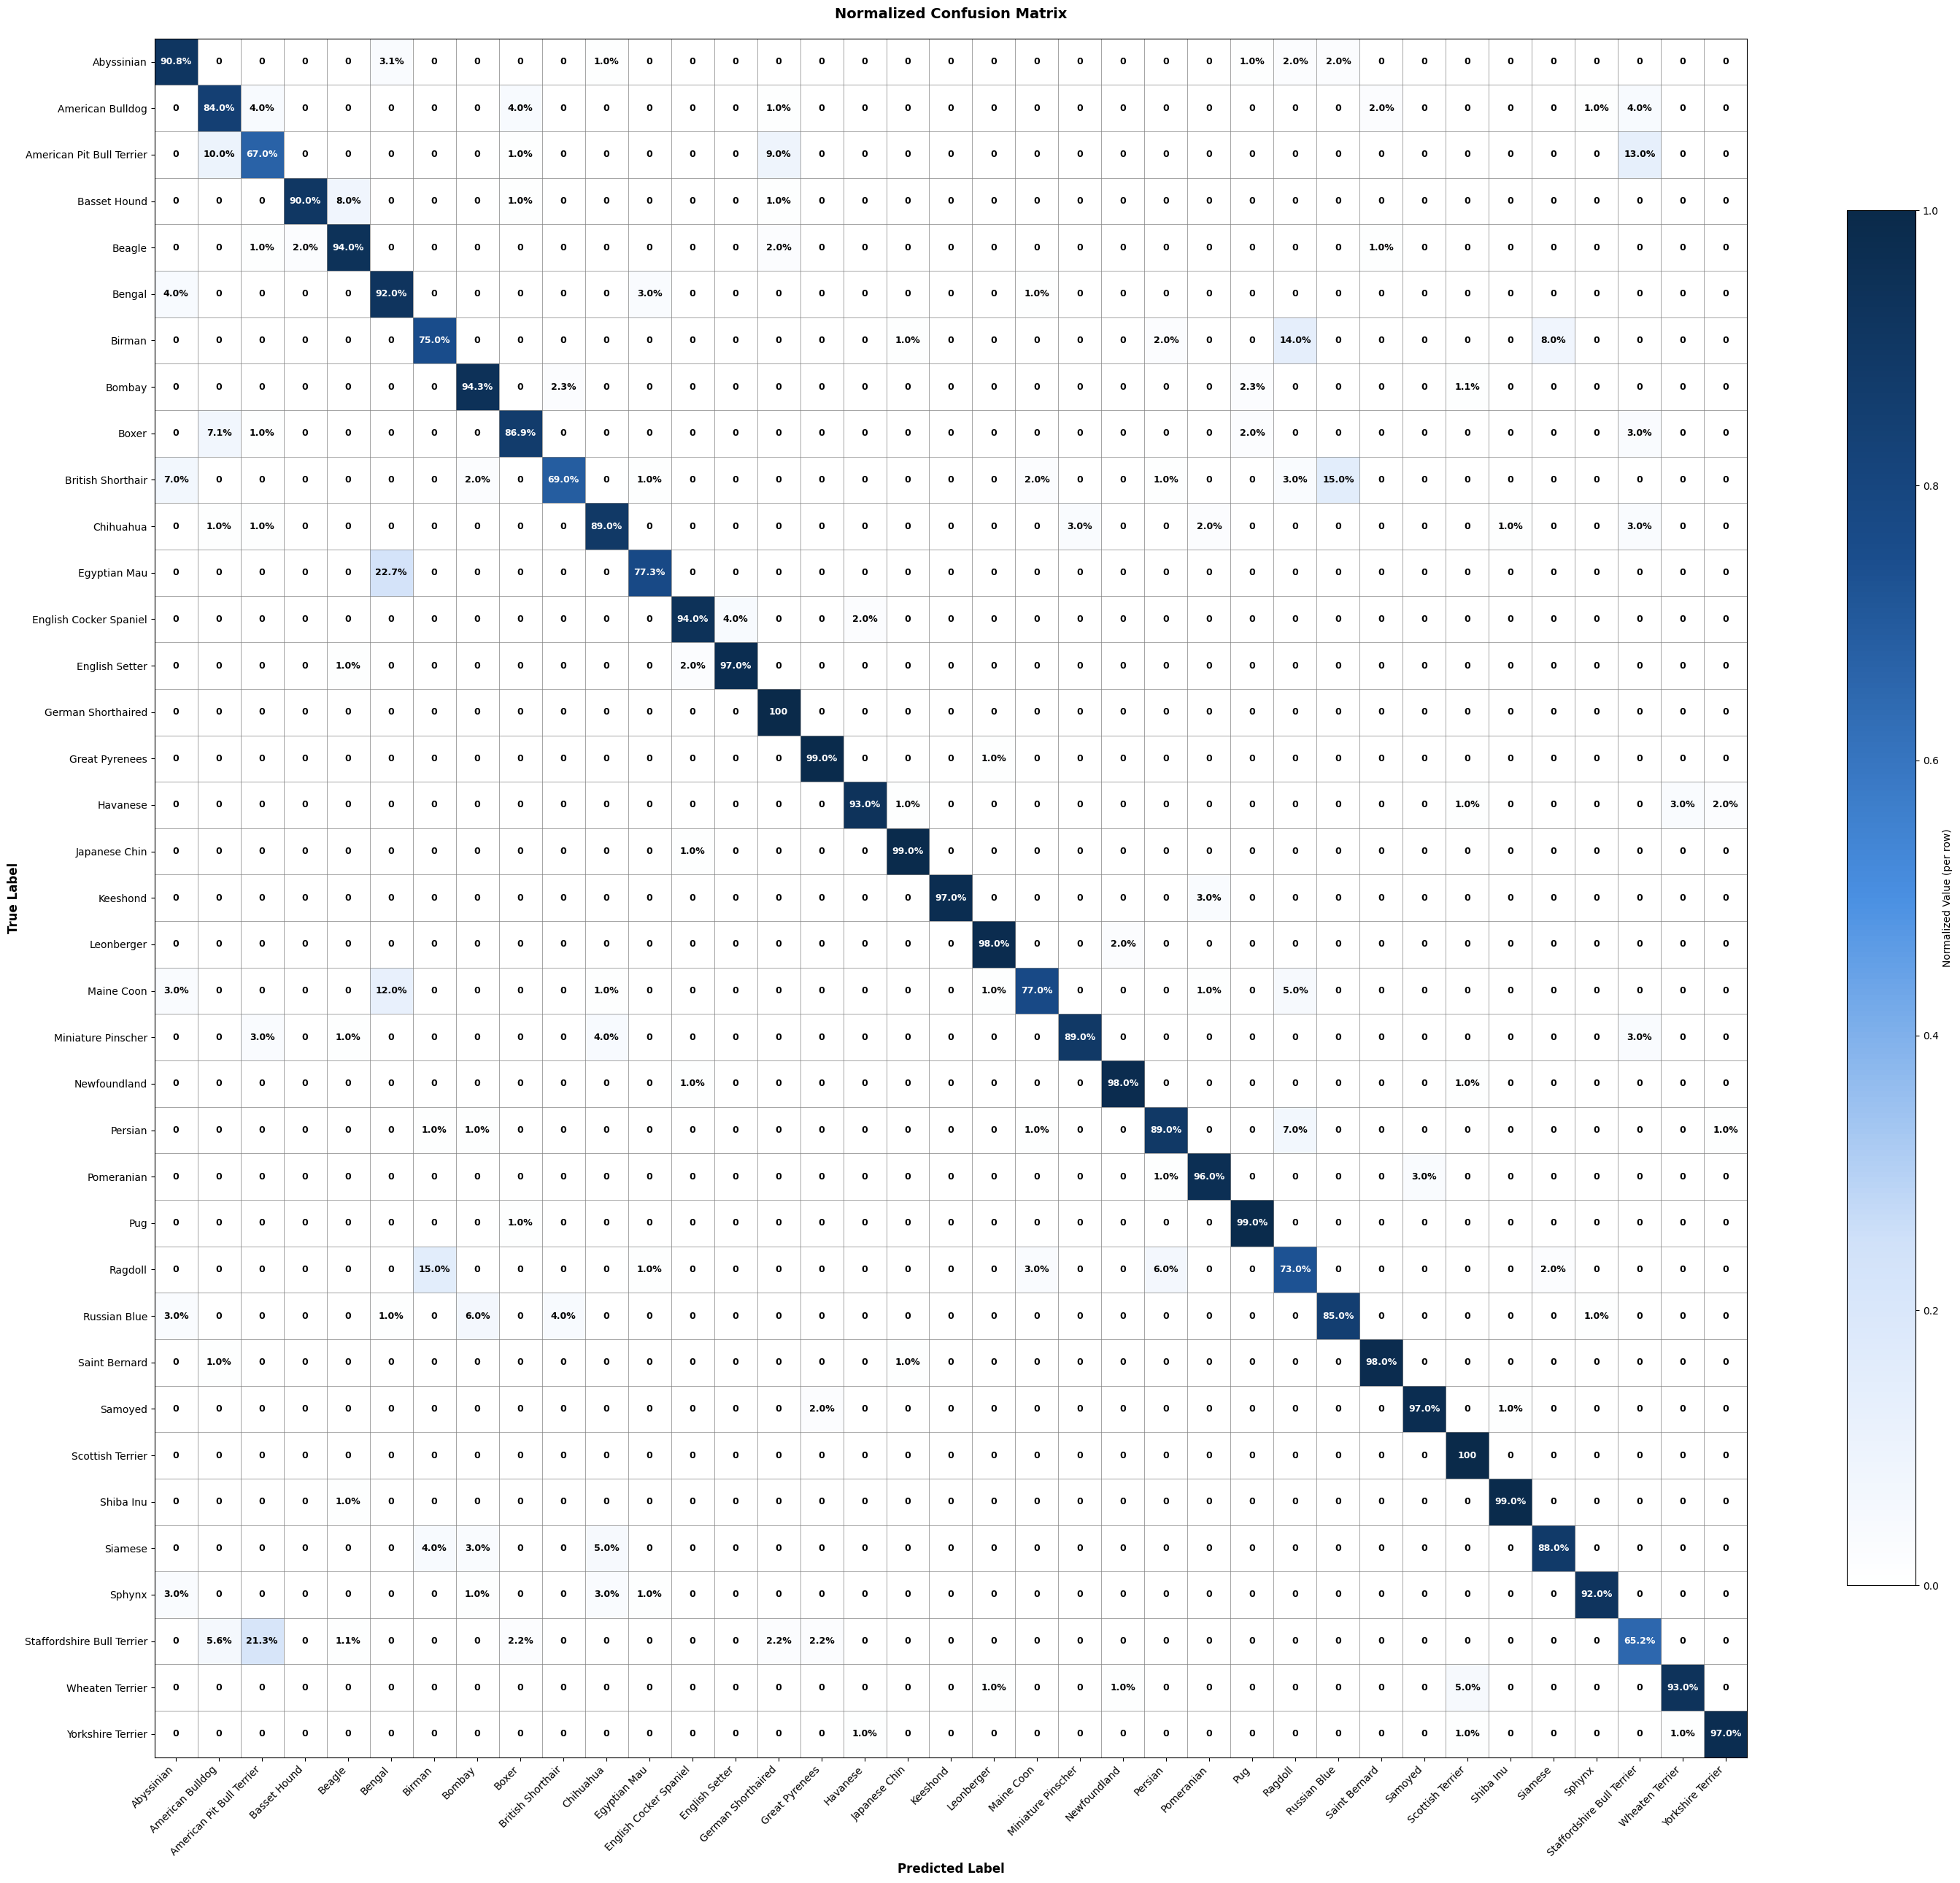

In [20]:
confusion_matrix(trainer.model, val_loader, config_model['device'], config_model['num_classes'], val_dataset.classes)

Моедль часто путает класс American Pit Bull Terrier с классом Staffordshire Bull Terrier.
Собаки похожи друг на друга  и имеют минимальные отличия.
Кошки - Egiptian Mau путает с Bengal.

### Resume

Моедль показала результат в 90%.  